In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use("default")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
data = load_digits()
X = data.data / 16.0
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

N = X_train.shape[0]

Training: 100%|██████████| 600/600 [00:07<00:00, 80.64it/s, epoch=49, loss=0.277]


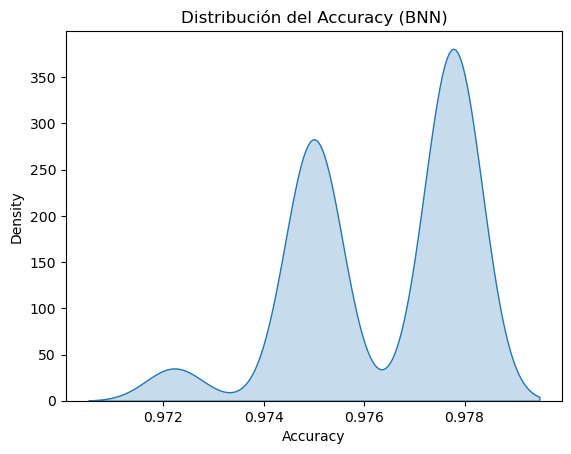

Mean: 0.976375
Std: 0.0016432836
Percentiles: [0.97486114 0.97777778 0.97777778]


In [22]:
# =========================
# 2. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 4. Bayesian Linear (vectorizada)
# =========================
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):

        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)
        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):


        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        if x.dim() == 2:
            x = x.unsqueeze(0).expand(n_samples, *x.shape)

        S = x.size(0)

        eps_w = torch.randn(S, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(S, *self.bias_mu.shape, device=x.device)

        weight = self.weight_mu + sigma_w * eps_w
        bias = self.bias_mu + sigma_b * eps_b

        out = torch.einsum("sbi,soi->sbo", x, weight) + bias.unsqueeze(1)

        return out

    def kl(self, mu, rho):

        sigma = torch.log1p(torch.exp(rho))

        return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

    def kl_loss(self):

        return self.kl(self.weight_mu, self.weight_rho) + self.kl(self.bias_mu, self.bias_rho)


# =========================
# 5. Red Bayesiana
# =========================
class BayesianNN(nn.Module):
    def __init__(self, prior_sigma=1.0):

        super().__init__()
        self.fc1 = BayesianLinear(64, 128, prior_sigma)
        self.fc2 = BayesianLinear(128, 64, prior_sigma)
        self.fc3 = BayesianLinear(64, 10, prior_sigma)

    def forward(self, x, n_samples=1):

        x = torch.relu(self.fc1(x, n_samples))
        x = torch.relu(self.fc2(x, n_samples))
        x = self.fc3(x, n_samples)

        return x

    def kl_loss(self):
        return self.fc1.kl_loss() + self.fc2.kl_loss() + self.fc3.kl_loss()


# =========================
# 6. ELBO (multi-sample)
# =========================
def elbo_loss(model, x, y, n_samples=1, beta=1e-4, N=None):
    logits = model(x, n_samples=n_samples)  # (S, B, C)

    S, B, C = logits.shape

    y_expand = y.unsqueeze(0).expand(S, B)

    logits_flat = logits.reshape(S * B, C)
    y_flat = y_expand.reshape(S * B)

    nll = F.cross_entropy(logits_flat, y_flat, reduction='mean')

    kl = model.kl_loss()/N

    loss = nll +  kl

    return loss


# =========================
# 7. Entrenamiento
# =========================
model = BayesianNN(prior_sigma=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs =50

progress_bar = tqdm(total=num_epochs * len(train_loader), desc="Training")

for epoch in range(num_epochs):
    model.train()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        loss = elbo_loss(model, x_batch, y_batch, n_samples=10)

        loss.backward()
        optimizer.step()

        # actualizar barra
        progress_bar.update(1)
        progress_bar.set_postfix({
            "epoch": epoch,
            "loss": f"{loss.item():.3f}"
        })

progress_bar.close()


# =========================
# 8. Muestras de accuracy (vectorizado)
# =========================
def sample_accuracies(model, X_test, y_test, n_samples=200):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        logits = model(X_test, n_samples=n_samples)  # (S, N, C)
        preds = logits.argmax(dim=2)

        correct = (preds == y_test.unsqueeze(0))
        accs = correct.float().mean(dim=1)

    return accs.cpu().numpy()


acc_samples = sample_accuracies(model, X_test, y_test, 200)


# =========================
# 9. Densidad del accuracy
# =========================
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (BNN)")
plt.show()


# =========================
# 10. Estadísticas
# =========================
print("Mean:", np.mean(acc_samples))
print("Std:", np.std(acc_samples))
print("Percentiles:", np.percentile(acc_samples, [5, 50, 95]))

In [23]:
class BayesianConv2d(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, prior_sigma=1.0):

        super().__init__()

        self.stride = stride
        self.padding = padding
        self.prior_sigma = prior_sigma

        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)

        # parámetros variacionales
        self.weight_mu = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )
        self.weight_rho = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )

        self.bias_mu = nn.Parameter(torch.empty(out_channels))
        self.bias_rho = nn.Parameter(torch.empty(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)

        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):
        # x: (B, C, H, W)

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        outputs = []

        for _ in range(n_samples):
            eps_w = torch.randn_like(self.weight_mu)
            eps_b = torch.randn_like(self.bias_mu)

            weight = self.weight_mu + sigma_w * eps_w
            bias = self.bias_mu + sigma_b * eps_b

            out = F.conv2d(
                x,
                weight,
                bias,
                stride=self.stride,
                padding=self.padding
            )

            outputs.append(out)

        return torch.stack(outputs)  # (S, B, C, H, W)

    def kl_loss(self):
        def kl(mu, rho):
            sigma = torch.log1p(torch.exp(rho))
            return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

        return kl(self.weight_mu, self.weight_rho) + kl(self.bias_mu, self.bias_rho)

In [24]:
class BayesianCNN(nn.Module):
    def __init__(self, prior_sigma=1.0):
        super().__init__()

        self.conv1 = BayesianConv2d(1, 16, 3, padding=1, prior_sigma=prior_sigma)
        self.conv2 = BayesianConv2d(16, 32, 3, padding=1, prior_sigma=prior_sigma)

        self.fc1 = BayesianLinear(32 * 2 * 2, 64, prior_sigma)
        self.fc2 = BayesianLinear(64, 10, prior_sigma)

        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x, n_samples=1):
        B = x.size(0)
        x = x.view(B, 1, 8, 8)

        # -------- Conv1 --------
        x = self.conv1(x, n_samples)      # (S, B, 16, 8, 8)
        x = torch.relu(x)

        S, B, C, H, W = x.shape
        x = x.view(S * B, C, H, W)
        x = self.pool(x)
        x = x.view(S, B, C, H//2, W//2)   # (S, B, 16, 4, 4)

        # -------- Conv2 --------
        x = x.view(S * B, 16, 4, 4)
        x = self.conv2(x, n_samples=1)    # (1, S*B, 32, 4, 4)
        x = torch.relu(x)

        # quitar dimensión extra de samples
        x = x.squeeze(0)                  # (S*B, 32, 4, 4)

        x = self.pool(x)                  # (S*B, 32, 2, 2)

        # -------- Flatten --------
        x = x.view(S, B, -1)              # (S, B, 32*2*2)

        # -------- FC --------
        x = torch.relu(self.fc1(x, n_samples))
        x = self.fc2(x, n_samples)

        return x

    def kl_loss(self):
        return (
            self.conv1.kl_loss() +
            self.conv2.kl_loss() +
            self.fc1.kl_loss() +
            self.fc2.kl_loss()
        )

In [25]:
model = BayesianCNN(prior_sigma=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
total_steps = num_epochs * len(train_loader)

with tqdm(total=total_steps, desc="Training", leave=True) as pbar:

    for epoch in range(num_epochs):
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            loss = elbo_loss(model, x_batch, y_batch, n_samples=1)

            loss.backward()
            optimizer.step()

            # actualizar barra
            pbar.update(1)
            pbar.set_postfix(loss=f"{loss.item():.3f}", epoch=epoch)


Training: 100%|██████████| 600/600 [00:09<00:00, 66.59it/s, epoch=49, loss=0.227]


In [26]:
def sample_accuracies(model, X_test, y_test, n_samples=200):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        logits = model(X_test, n_samples=n_samples)  # (S, N, C)
        preds = logits.argmax(dim=2)                # (S, N)

        correct = (preds == y_test.unsqueeze(0))    # (S, N)
        accs = correct.float().mean(dim=1)          # (S,)

    return accs.cpu().numpy()
acc_samples = sample_accuracies(model, X_test, y_test, n_samples=200)

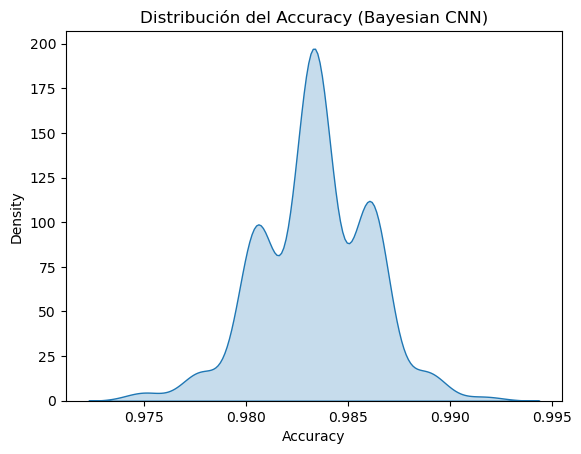

In [27]:
import matplotlib.pyplot as plt
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (Bayesian CNN)")
plt.show()

In [28]:
np.quantile(acc_samples, [0.05, 0.95])

array([0.98055559, 0.98611116])

In [17]:
for name, param in model.named_parameters():
    print(name, param)

conv1.weight_mu Parameter containing:
tensor([[[[ 0.1798,  0.6101, -0.2899],
          [ 0.3221,  0.1112, -0.0912],
          [-0.4319, -0.8188, -0.7701]]],


        [[[ 0.8722,  0.2895,  0.0119],
          [ 0.3161,  0.3275,  0.2718],
          [ 0.1717,  0.6438, -0.1834]]],


        [[[ 0.6278, -0.2821, -0.8676],
          [-0.0435,  0.4150,  0.1467],
          [ 0.4676,  0.8118,  0.1405]]],


        [[[ 0.0530,  0.6625, -0.1293],
          [ 0.1623,  0.0172, -0.0494],
          [-0.6047, -0.4629, -0.6716]]],


        [[[ 0.2042, -0.4994,  0.3960],
          [ 1.0442, -0.0531,  0.4254],
          [ 0.0643, -0.4771, -0.5364]]],


        [[[-0.4286,  0.4182,  0.0707],
          [ 0.9931,  0.5454,  0.1775],
          [ 0.2750,  0.8998, -0.4750]]],


        [[[-0.2752,  0.0768,  0.5268],
          [-0.5372, -0.6827,  0.2696],
          [-0.6638,  0.8559, -0.7509]]],


        [[[-0.0736, -0.6350,  0.5997],
          [ 0.3744, -0.6926, -0.1379],
          [-0.2294,  0.1582,  0.8174]